In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv('/home/intellect-1001/Downloads/citydata.csv')
df.head()

,Unnamed: 0,X,Y
0,City 1,54.48,-65.51
1,City 2,-0.01,70.40
2,City 3,-31.84,52.78
3,City 4,7.44,110.81
4,City 5,0.48,-8.14


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  60 non-null     object 
 1   X           60 non-null     float64
 2   Y           60 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.5+ KB


In [4]:
X = df.select_dtypes(include=['float64', 'int64'])


In [5]:
print(X.head())

       X       Y
0  54.48  -65.51
1  -0.01   70.40
2 -31.84   52.78
3   7.44  110.81
4   0.48   -8.14


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

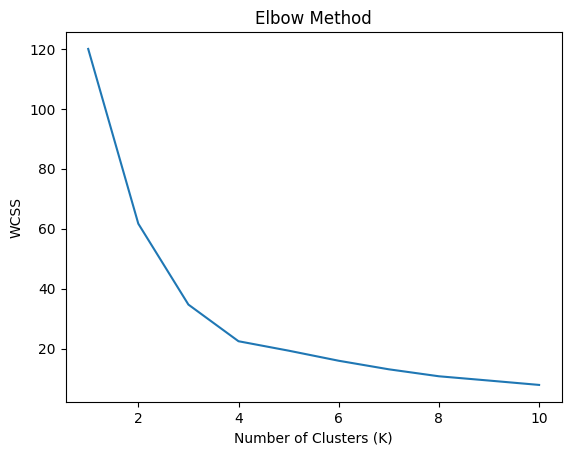

In [7]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
print(df.head())


  Unnamed: 0      X       Y  Cluster
0     City 1  54.48  -65.51        1
1     City 2  -0.01   70.40        2
2     City 3 -31.84   52.78        0
3     City 4   7.44  110.81        2
4     City 5   0.48   -8.14        0


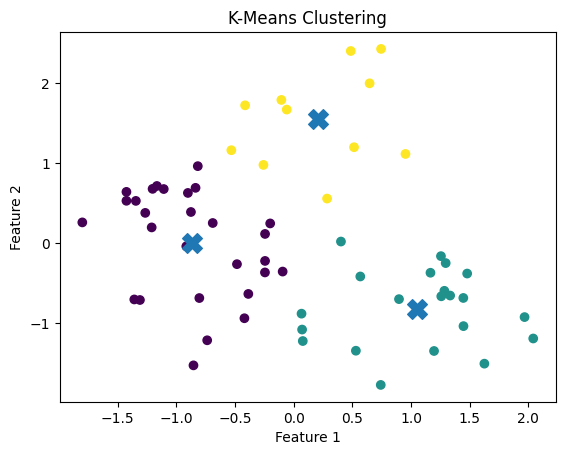

In [9]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")
plt.show()


In [10]:
import joblib
joblib.dump(kmeans, "kmeans_model.pkl")


['kmeans_model.pkl']